<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div style="text-align: center; margin-bottom: 10px;">
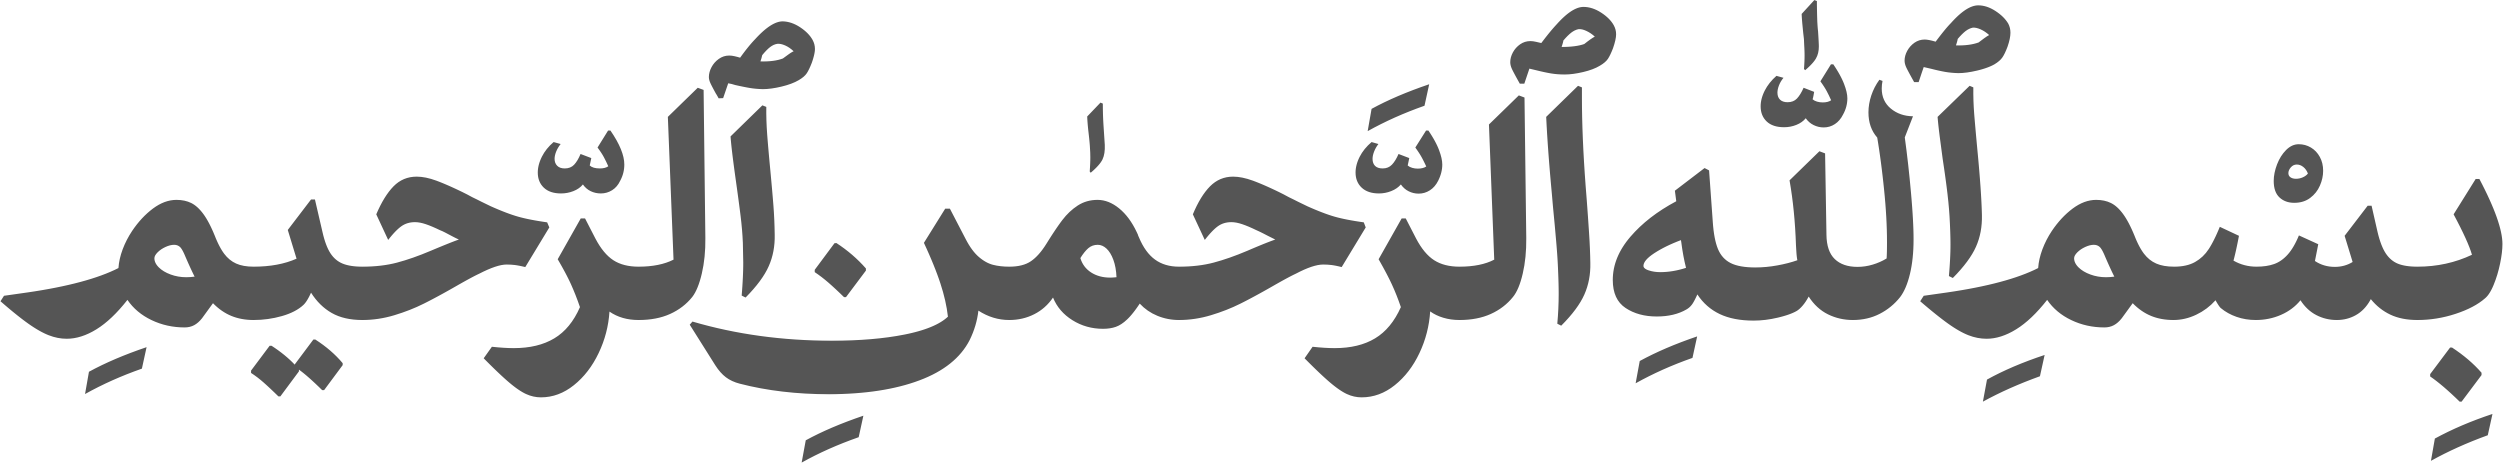
<div style="margin-top: 18px; display: flex; justify-content: center; align-items: center; gap: 30px;">
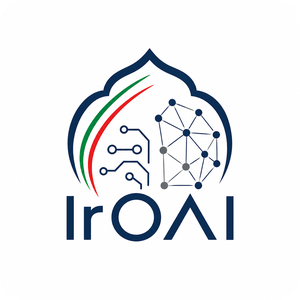
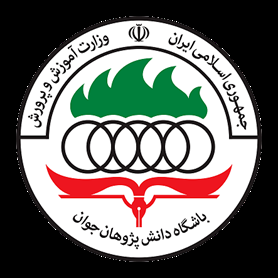
</div>
</div>
<h1 style="text-align: right;color: var(--jp-content-font-color1, #1e6bb8);">تمرین عملی المپیاد هوش مصنوعی — دوره دوم (۱۴۰۴-۱۴۰۵)</h1>
<h2 style="text-align: right;color: #3498db;">شبکه‌های عصبی چندلایه (MLP) با PyTorch و پیاده‌سازی بهینه‌سازها</h2>
<p style="text-align: right;"><b>موضوع:</b> شبکه‌های عصبی چندلایه، آموزش با گرادیان کاهشی، PyTorch، بهینه‌سازهای GD و Momentum</p>
<p style="text-align: right;color: var(--jp-ui-font-color2, #6b7280);">این یک تمرین آموزشی است؛ هیچ نمره‌ای از سامانه داوری دریافت نمی‌کند. هدف، یادگیری و بررسی نتیجه کار خودتان است.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">مقدمه</h2>
<p style="text-align: right;">تا اینجا با مجموعه‌ای از الگوریتم‌های یادگیری ماشین کلاسیک کار کرده‌اید: رگرسیون خطی، رگرسیون لجستیک، بیز ساده، روش‌های گروهی (ensemble). این مدل‌ها ابزارهای قدرتمندی هستند، اما تقریباً همه‌ی آن‌ها یک محدودیت مشترک دارند: <strong>توانایی محدود در مدل‌کردن روابط غیرخطی پیچیده بین ویژگی‌ها</strong> — مثلاً رگرسیون خطی فقط یک ابرصفحه برازش می‌دهد و رگرسیون لجستیک فقط مرز تصمیم خطی می‌سازد.</p>
<p style="text-align: right;"><strong>شبکه‌ی عصبی چندلایه (MLP)</strong> تعمیم مستقیم همان مدل‌هایی است که می‌شناسید: چند «رگرسیون خطی» پشت سر هم که بین آن‌ها یک <strong>تابع فعال‌سازی غیرخطی</strong> قرار می‌گیرد. با همین ایده‌ی ساده، شبکه‌ای می‌سازیم که می‌تواند هر تابع پیوسته‌ی معقولی را تقریب بزند.</p>
<p style="text-align: right;">در این تمرین اول <strong>تئوری MLP را مرور می‌کنیم</strong> و بعد همه‌چیز را در کد پیاده می‌کنیم:</p>
<ol style="text-align: right;">
<li style="text-align: right;">آشنایی با PyTorch و محاسبه‌ی خودکار گرادیان (autograd)</li>
<li style="text-align: right;">حل یک <strong>مسئله‌ی رگرسیون</strong> غیرخطی با MLP</li>
<li style="text-align: right;">حل یک <strong>مسئله‌ی دسته‌بندی</strong> (دو هلال) با MLP و رسم مرز تصمیم</li>
<li style="text-align: right;">پیاده‌سازی بهینه‌ساز <code dir="ltr">VanillaGD</code> — گرادیان کاهشی ساده — با استفاده از گرادیان‌های خودِ PyTorch</li>
<li style="text-align: right;">پیاده‌سازی بهینه‌ساز <code dir="ltr">MomentumGD</code> و مقایسه‌ی سرعت همگرایی</li>
<li style="text-align: right;">فاز ارزیابی: مقایسه‌ی نتیجه‌ی کار خودتان با راه‌حل مرجع</li>
</ol>
<p style="text-align: right;">همه‌ی بخش‌های اصلی کد را خودتان می‌نویسید؛ سلول‌های خواندنی فقط داده و ابزارهای کمکی را فراهم می‌کنند.</p>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">مرور تئوری (۱) — از مدل خطی تا شبکه‌ی چندلایه</h2>
<p style="text-align: right;">نقطه‌ی شروع ما مدلی است که خوب می‌شناسید: <strong>رگرسیون خطی</strong>. برای ورودی $\mathbf{x}$ خروجی را به‌صورت ترکیب خطی ویژگی‌ها به‌علاوه‌ی بایاس می‌سازد:</p>

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b$$

<p style="text-align: right;">در <strong>رگرسیون لجستیک</strong> همین ترکیب خطی از یک تابع سیگموئید عبور می‌کند تا عددی بین ۰ و ۱ (احتمال تعلق به کلاس) بدهد:</p>

$$\hat{p} = \sigma(\mathbf{w}^\top \mathbf{x} + b), \qquad \sigma(z) = \frac{1}{1+e^{-z}}$$

<p style="text-align: right;">هر دو مدل فقط به <strong>توابع خطی از ورودی</strong> دسترسی دارند؛ به همین دلیل مرز تصمیم رگرسیون لجستیک همیشه یک خط (یا ابرصفحه) است. شاید فکر کنید «چند لایه‌ی خطی را پشت هم بگذاریم مشکل حل می‌شود» — اما ترکیب هر تعداد تبدیل خطی، خودش یک تبدیل خطی است:</p>

$$W_2(W_1 \mathbf{x}) = (W_2 W_1)\,\mathbf{x}$$

<p style="text-align: right;">پس چیدن لایه‌های خطی پشت سر هم <strong>هیچ قدرت بیان جدیدی اضافه نمی‌کند</strong>. کلید حل مسئله، قرار دادن یک <strong>تابع فعال‌سازی غیرخطی</strong> بعد از هر لایه‌ی خطی است. یک MLP با $L$ لایه‌ی پنهان به این صورت تعریف می‌شود:</p>

$$\mathbf{h}^{(l)} = \sigma\!\left(W^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}\right), \qquad l = 1, \dots, L, \qquad \mathbf{h}^{(0)} = \mathbf{x}$$

<p style="text-align: right;">و لایه‌ی خروجی:</p>
<ul style="text-align: right;">
<li style="text-align: right;">در <strong>رگرسیون</strong>: یک لایه‌ی خطی ساده (بدون فعال‌سازی) که یک عدد پیوسته می‌دهد.</li>
<li style="text-align: right;">در <strong>دسته‌بندی</strong>: یک لایه‌ی خطی که برای هر کلاس یک logit می‌دهد (در این تمرین دقیقاً همین را پیاده می‌کنید).</li>
</ul>
<p style="text-align: right;">نتیجه‌ی معروف <strong>قضیه‌ی تقریب جهانی</strong> این است: یک MLP با حتی یک لایه‌ی پنهان و تعداد کافی نورون می‌تواند هر تابع پیوسته‌ی معقولی روی یک ناحیه‌ی فشرده را با دقت دلخواه تقریب بزند. (البته این قضیه نمی‌گوید شبکه‌ی ما در عمل چقدر بزرگ لازم دارد یا چطور خوب آموزش می‌بیند!)</p>
<p style="text-align: right;"><strong>نکته‌ی جالب:</strong> اگر در یک MLP فعال‌سازی‌ها را خطی بگذاریم، دقیقاً به رگرسیون خطی برمی‌گردیم؛ یعنی MLP اکیداً تعمیمِ مدل‌های آشنای شماست، نه چیزی کاملاً جدید.</p>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">مرور تئوری (۲) — توابع فعال‌سازی</h2>
<p style="text-align: right;">همان‌طور که دیدیم، غیرخطی بودن $\sigma$ تنها دلیل قدرت MLP است. سه تابع فعال‌سازی پرکاربرد:</p>

$$\mathrm{ReLU}(z) = \max(0, z)$$

$$\sigma(z) = \frac{1}{1+e^{-z}}$$

$$\tanh(z) = \frac{e^{z}-e^{-z}}{e^{z}+e^{-z}}$$

<ul style="text-align: right;">
<li style="text-align: right;"><strong>ReLU:</strong> ساده و ارزان؛ برای $z > 0$ گرادیان دقیقاً ۱ است (بدون محوشدگی)؛ اما نورون‌هایی که همیشه در ناحیه‌ی $z \le 0$ بیفتند «می‌میرند» (گرادیان صفر). امروز انتخاب پیش‌فرض لایه‌های پنهان است.</li>
<li style="text-align: right;"><strong>سیگموئید:</strong> خروجی در $(0, 1)$ و به‌راحتی به‌صورت احتمال تفسیر می‌شود؛ اما برای $|z|$ بزرگ اشباع می‌شود و گرادیان تقریباً صفر می‌شود (مشکل <em>vanishing gradient</em> در شبکه‌های عمیق). خروجی آن صفر-مرکزی هم نیست.</li>
<li style="text-align: right;"><strong>tanh:</strong> مثل سیگموئید ولی با خروجی صفر-مرکزی در $(-1, 1)$؛ باز هم در نقاط اشباع گرادیان محو می‌شود.</li>
</ul>
<p style="text-align: right;">در این تمرین برای لایه‌های پنهان از <strong>ReLU</strong> استفاده می‌کنیم. توجه کنید که تابع فعال‌سازی <strong>تابعی از یک عدد</strong> است که مؤلفه‌به‌مؤلفه (element-wise) روی بردار اعمال می‌شود.</p>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">مرور تئوری (۳) — تابع هزینه، گرادیان کاهشی و پس‌انتشار</h2>
<p style="text-align: right;">شبکه را با کمینه‌کردن یک <strong>تابع هزینه</strong> روی داده‌ی آموزش آموزش می‌دهیم. برای رگرسیون، میانگین مربعات خطا:</p>

$$L_{\mathrm{MSE}} = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2$$

<p style="text-align: right;">و برای دسته‌بندی چندکلاسه، <strong>آنتروپی متقاطع</strong>؛ اگر $\hat{p}_{i,c}$ احتمال پیش‌بینی‌شده‌ی کلاس $c$ برای نمونه‌ی $i$ و $c_i$ برچسب درست باشد:</p>

$$L_{\mathrm{CE}} = -\frac{1}{n}\sum_{i=1}^{n} \log \hat{p}_{i,\,c_i}$$

<p style="text-align: right;">هدف، یافتن همه‌ی پارامترهای شبکه $\theta = \{W^{(l)}, \mathbf{b}^{(l)}\}$ است که این هزینه را کمینه می‌کنند. با <strong>گرادیان کاهشی (Gradient Descent)</strong> از موقعیت فعلی یک گام کوچک در جهت گرادیان منفی برمی‌داریم:</p>

$$\theta \leftarrow \theta - \eta\, \nabla_\theta L(\theta)$$

<p style="text-align: right;">که $\eta$ <strong>نرخ یادگیری</strong> است: بزرگ باشد دچار نوسان و واگرایی می‌شویم، کوچک باشد آموزش کُند می‌شود. در این تمرین همه‌ی داده را یک‌جا می‌دهیم (full-batch)؛ در عمل معمولاً mini-batch استفاده می‌شود.</p>
<p style="text-align: right;"><strong>پس‌انتشار (backpropagation)</strong> چیزی جز قاعده‌ی زنجیره‌ای برای محاسبه‌ی کارآمد گرادیان هزینه نسبت به همه‌ی پارامترها نیست. خبر خوب: PyTorch با موتور <strong>autograd</strong> این محاسبه را کاملاً خودکار انجام می‌دهد — کافی است هزینه را بنویسید و <code dir="ltr">loss.backward()</code> را صدا بزنید تا گرادیان همه‌ی پارامترها در <code dir="ltr">param.grad</code> قرار بگیرد. در فازهای ۷ و ۸ دقیقاً از همین گرادیان‌ها برای ساختن بهینه‌ساز خودمان استفاده می‌کنیم.</p>
</div>


In [1]:
# Setup - read-only cell; do not edit (but DO run it)
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression

SEED = 1001
np.random.seed(SEED)
torch.manual_seed(SEED)

print("torch", torch.__version__, "| numpy", np.__version__, "| sklearn ready")

torch 2.13.0+cpu | numpy 2.5.1 | sklearn ready


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۰ — آشنایی با PyTorch و autograd</h2>
<p style="text-align: right;">PyTorch دو ابزار اصلی دارد که در این تمرین استفاده می‌کنیم:</p>
<ul style="text-align: right;">
<li style="text-align: right;"><code dir="ltr">torch.Tensor</code>: مثل آرایه‌ی NumPy، ولی با امکان <strong>ثبت عملیات</strong> برای محاسبه‌ی گرادیان. اگر <code dir="ltr">requires_grad=True</code> باشد، PyTorch هر عملیاتی را که روی آن انجام می‌شود برای پس‌انتشار ذخیره می‌کند.</li>
<li style="text-align: right;"><code dir="ltr">loss.backward()</code>: پس‌انتشار را اجرا می‌کند و گرادیان را در <code dir="ltr">.grad</code> هر پارامتر می‌ریزد.</li>
</ul>
<p style="text-align: right;">سلول زیر را اجرا کنید: یک مسئله‌ی خیلی ساده — کمینه‌کردن $f(w) = (w-3)^2$ — را دستی و با گرادیان کاهشی حل می‌کنیم. گرادیان تحلیلی $f'(w) = 2(w-3)$ است؛ همان چیزی که <code dir="ltr">backward</code> خودش محاسبه می‌کند:</p>
</div>


In [16]:
# Autograd warm-up - read-only cell; do not edit (but DO run it)
w = torch.tensor(0.0, requires_grad=True)   # the parameter we want to learn

for step in range(10):
    loss = (w - 3.0) ** 2                   # f(w) = (w - 3)^2
    loss.backward()                         # computes dL/dw = 2(w - 3)
    print(f"step {step}: w = {w.item():.4f}  grad = {w.grad.item():+.4f}")
    with torch.no_grad():                   # manual gradient-descent update
        w -= 0.30 * w.grad
    w.grad = None                           # reset the gradient (important!)

print(f"final w = {w.item():.4f}  (the optimum is w = 3.0)")

step 0: w = 0.0000  grad = -6.0000
step 1: w = 1.8000  grad = -2.4000
step 2: w = 2.5200  grad = -0.9600
step 3: w = 2.8080  grad = -0.3840
step 4: w = 2.9232  grad = -0.1536
step 5: w = 2.9693  grad = -0.0614
step 6: w = 2.9877  grad = -0.0246
step 7: w = 2.9951  grad = -0.0098
step 8: w = 2.9980  grad = -0.0039
step 9: w = 2.9992  grad = -0.0016
final w = 2.9997  (the optimum is w = 3.0)


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۱ — داده‌ی رگرسیون: چرا خط کافی نیست؟</h2>
<p style="text-align: right;">داده‌ی رگرسیون ما از تابع زیر ساخته می‌شود؛ $x$ یکنواخت از بازه‌ی $[-3, 3]$ نمونه‌برداری می‌شود و نویز گاوسی با انحراف معیار $0.15$ اضافه می‌شود:</p>

$$y = 0.2\,x + \sin(1.5\,x) + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\, 0.15^2)$$

<p style="text-align: right;">سلول زیر (که نباید تغییرش دهید) داده را می‌سازد و این متغیرها را تولید می‌کند:</p>
<ul style="text-align: right;">
<li style="text-align: right;"><code dir="ltr">X_reg</code> و <code dir="ltr">y_reg</code>: داده‌ی آموزش با شکل‌های <code dir="ltr">(400, 1)</code> و <code dir="ltr">(400, 1)</code></li>
<li style="text-align: right;"><code dir="ltr">X_reg_test</code> و <code dir="ltr">y_reg_test</code>: داده‌ی تست (۲۰۰ نمونه) برای فاز ارزیابی</li>
</ul>
<p style="text-align: right;"><strong>توجه:</strong> ورودی با میانگین و انحراف معیار داده‌ی آموزش <strong>استانداردسازی</strong> شده است — این یک عادت خوب در یادگیری عمیق است و بهینه‌سازی را پایدارتر می‌کند (اثرش را در فازهای ۷ و ۸ بهتر می‌بینید).</p>
</div>


X_reg: (400, 1) | y_reg: (400, 1) | X_reg_test: (200, 1) | y_reg_test: (200, 1)


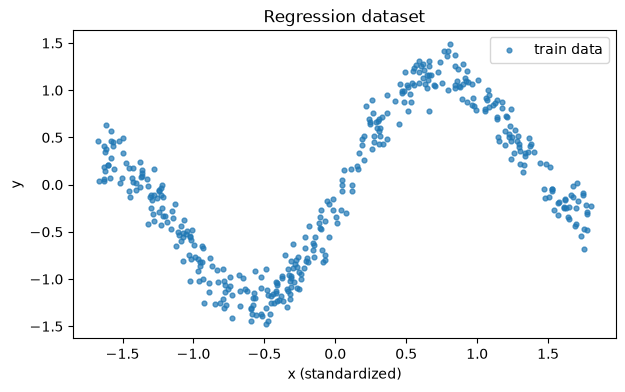

In [3]:
# Data generation - read-only cell; do not edit (but DO run it)
def make_reg_data(n, seed):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-3.0, 3.0, size=(n, 1))
    y = 0.2 * x[:, 0] + np.sin(1.5 * x[:, 0]) + rng.normal(0.0, 0.15, size=n)
    return x.astype(np.float32), y.astype(np.float32)

x_tr, y_tr = make_reg_data(400, SEED)
x_te, y_te = make_reg_data(200, SEED + 1000)

x_mean, x_std = float(x_tr.mean()), float(x_tr.std())
X_reg      = torch.tensor((x_tr - x_mean) / x_std)   # (400, 1)
y_reg      = torch.tensor(y_tr).unsqueeze(1)         # (400, 1)
X_reg_test = torch.tensor((x_te - x_mean) / x_std)   # (200, 1)
y_reg_test = torch.tensor(y_te).unsqueeze(1)         # (200, 1)

print("X_reg:", tuple(X_reg.shape), "| y_reg:", tuple(y_reg.shape),
      "| X_reg_test:", tuple(X_reg_test.shape), "| y_reg_test:", tuple(y_reg_test.shape))

plt.figure(figsize=(7, 4))
plt.scatter(X_reg.numpy(), y_reg.numpy(), s=12, alpha=0.7, label="train data")
plt.xlabel("x (standardized)")
plt.ylabel("y")
plt.title("Regression dataset")
plt.legend()
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">بحث کنید</h2>
<ul style="text-align: right;">
<li style="text-align: right;">با نگاه به نمودار داده: آیا رگرسیون خطی می‌تواند این رابطه را خوب مدل کند؟ «بهترین خط ممکن» تقریباً چقدر خطا دارد؟</li>
<li style="text-align: right;">چه نوع توابعی برای برازش این داده لازم است؟</li>
</ul>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۲ — پیاده‌سازی MLP برای رگرسیون</h2>
<p style="text-align: right;">اولین چیزی که خودتان می‌نویسید! کلاس <code dir="ltr">MLPRegressor</code> را با این مشخصات تعریف کنید:</p>
<pre dir="ltr">class MLPRegressor(nn.Module):
    def __init__(self, in_dim=1, hidden_dims=(64, 64), out_dim=1):
        ...
    def forward(self, x):
        ...</pre>
<ul style="text-align: right;">
<li style="text-align: right;">معماری: برای هر بعد در <code dir="ltr">hidden_dims</code> یک <code dir="ltr">nn.Linear</code> + <code dir="ltr">ReLU</code>، و در انتها یک <code dir="ltr">nn.Linear</code> بدون فعال‌سازی (خروجی رگرسیون).</li>
<li style="text-align: right;"><code dir="ltr">forward(x)</code> خروجی با شکل <code dir="ltr">(n, out_dim)</code> برمی‌گرداند.</li>
</ul>
<details style="text-align: right;"><summary style="text-align: right;">راهنمایی</summary><p style="text-align: right;">می‌توانید لایه‌ها را در یک <code dir="ltr">nn.Sequential</code> جمع کنید یا با <code dir="ltr">nn.ModuleList</code> در <code dir="ltr">forward</code> پیمایش کنید. یک راه ساده: لیست ابعاد <code dir="ltr">[in_dim, *hidden_dims, out_dim]</code> بسازید و روی جفت‌های متوالی آن حلقه بزنید.</p></details>
<p style="text-align: right;">بعد از تعریف، یک نمونه با مقادیر پیش‌فرض بسازید (قبل از ساخت مدل <code dir="ltr">torch.manual_seed(SEED)</code> را اجرا کنید) و مدل را چاپ کنید تا ساختارش را ببینید.</p>
</div>


In [4]:
# TODO: Define the 'MLPRegressor' class (subclass of torch.nn.Module) with signature:
#   MLPRegressor(in_dim=1, hidden_dims=(64, 64), out_dim=1)
# Architecture: for each dim in hidden_dims, one nn.Linear followed by ReLU;
# then a final nn.Linear (identity output, no activation).

# TODO: run torch.manual_seed(SEED), create an instance with default arguments,
# and print the model to inspect its layers.

class MLPRegressor(nn.Module):
    def __init__(self, in_dim=1, hidden_dims=(64, 64), out_dim=1):
        super().__init__()
        dims = [in_dim, *hidden_dims, out_dim]
        layers = []
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


torch.manual_seed(SEED)
reg_model = MLPRegressor()
print(reg_model)

MLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۳ — حلقه‌ی آموزش (Training Loop)</h2>
<p style="text-align: right;">قلب یادگیری عمیق: حلقه‌ای که در هر گام گرادیان هزینه را محاسبه و پارامترها را با بهینه‌ساز به‌روزرسانی می‌کند. تابع عمومی زیر را پیاده کنید که هم برای رگرسیون و هم دسته‌بندی و هم با بهینه‌سازهای خودتان (فازهای ۷ و ۸) کار کند:</p>
<pre dir="ltr">def train_model(model, X, y, optimizer, loss_fn, epochs=400, log_every=100):
    # full-batch training loop
    # returns: list of per-epoch losses (Python floats)
    ...</pre>
<p style="text-align: right;">هر گام (epoch) شامل:</p>
<ol style="text-align: right;">
<li style="text-align: right;"><code dir="ltr">optimizer.zero_grad()</code> — گرادیان قبلی پاک شود (وگرنه گرادیان‌ها جمع می‌شوند!)</li>
<li style="text-align: right;">محاسبه‌ی هزینه: <code dir="ltr">loss = loss_fn(model(X), y)</code></li>
<li style="text-align: right;"><code dir="ltr">loss.backward()</code> — پر شدن <code dir="ltr">.grad</code> پارامترها</li>
<li style="text-align: right;"><code dir="ltr">optimizer.step()</code> — به‌روزرسانی پارامترها</li>
</ol>
<p style="text-align: right;">هزینه‌ی هر گام را با <code dir="ltr">loss.item()</code> به لیست خروجی اضافه کنید. اگر <code dir="ltr">log_every</code> برابر <code dir="ltr">None</code> نباشد، هر <code dir="ltr">log_every</code> گام شماره‌ی گام و هزینه‌ی فعلی را چاپ کنید. (داده full-batch است؛ shuffle لازم نیست.)</p>
</div>


In [5]:
# TODO: Define the 'train_model' function with the following signature:
#   train_model(model, X, y, optimizer, loss_fn, epochs=400, log_every=100)
#   -> list of per-epoch losses (Python floats)
#   1) calcualte the loss using the loss_fn, model, X and y
#   2) set the gradients of parameters as None using the optimizer
#   3) calculate the gradients of loss with respect to parameters ( backward process ) and update the parameters
#   4) append loss.item() to the loss list
# If log_every is not None, print the epoch number and current loss every 'log_every' epochs.
# return the losses list as the end
def train_model(model, X, y, optimizer, loss_fn, epochs=400, log_every=100):
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if log_every is not None and (epoch + 1) % log_every == 0:
            print(f"epoch {epoch + 1:4d} | loss = {losses[-1]:.6f}")
    return losses

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۴ — آموزش رگرسیون و مقایسه با خط پایه‌ی خطی</h2>
<p style="text-align: right;">حالا همه‌چیز را کنار هم بگذارید:</p>
<ol style="text-align: right;">
<li style="text-align: right;">اول <code dir="ltr">torch.manual_seed(SEED)</code> (برای تکرارپذیری)؛ بعد یک <code dir="ltr">MLPRegressor()</code> بسازید.</li>
<li style="text-align: right;">آن را با بهینه‌ساز <code dir="ltr">torch.optim.Adam</code> (با <code dir="ltr">lr=0.01</code>) و <code dir="ltr">nn.MSELoss()</code> برای ۴۰۰ گام با <code dir="ltr">train_model</code> آموزش دهید.</li>
<li style="text-align: right;">یک <strong>خط پایه‌ی خطی</strong> هم با <code dir="ltr">np.polyfit(x, y, 1)</code> روی داده‌ی آموزش برازش دهید.</li>
<li style="text-align: right;">در یک شکل: پراکندگی داده‌ی آموزش، منحنی پیش‌بینی MLP روی یک شبکه‌ی متراکم از مقادیر x، و خط پایه را رسم کنید (با legend).</li>
<li style="text-align: right;">هزینه‌ی نهایی آموزش و MSE مدل روی داده‌ی تست را چاپ کنید (داخل <code dir="ltr">torch.no_grad()</code>).</li>
</ol>
</div>


epoch  100 | loss = 0.024232
epoch  200 | loss = 0.023156
epoch  300 | loss = 0.025808
epoch  400 | loss = 0.022783


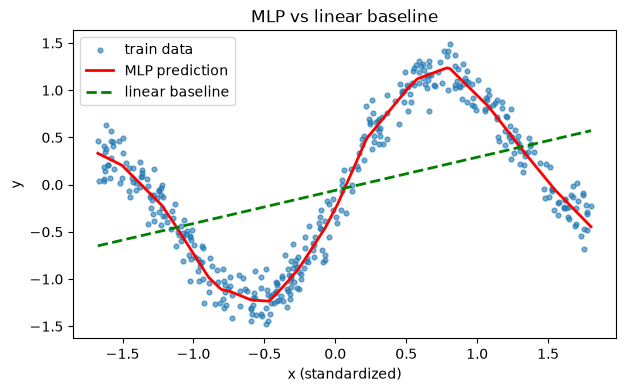

final train loss = 0.0228 | MLP test MSE = 0.0240


In [6]:
# TODO: train an MLPRegressor on the regression data:
#   torch.manual_seed(SEED); model = MLPRegressor()
#   define the optimizer as one of pytorch's optimizers and set it's learning rate
#   define loss_fn as the pytorch's MSE Loss
#   losses = train_model(model, X_reg, y_reg, optimizer, loss_fn, epochs=400, log_every=100)

# TODO: fit a linear baseline with np.polyfit(x, y, 1) on the training data

torch.manual_seed(SEED)
model = MLPRegressor()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()
losses = train_model(model, X_reg, y_reg, optimizer, loss_fn, epochs=400, log_every=100)

a, b = np.polyfit(X_reg.numpy().flatten(), y_reg.numpy().flatten(), 1)

with torch.no_grad():
    x_grid = torch.linspace(X_reg.min(), X_reg.max(), 400).unsqueeze(1)
    y_mlp = model(x_grid).numpy().flatten()
    test_mse = loss_fn(model(X_reg_test), y_reg_test).item()

x_line = x_grid.numpy().flatten()
plt.figure(figsize=(7, 4))
plt.scatter(X_reg.numpy(), y_reg.numpy(), s=12, alpha=0.6, label="train data")
plt.plot(x_line, y_mlp, "r-", lw=2, label="MLP prediction")
plt.plot(x_line, a * x_line + b, "g--", lw=2, label="linear baseline")
plt.xlabel("x (standardized)")
plt.ylabel("y")
plt.title("MLP vs linear baseline")
plt.legend()
plt.show()

print(f"final train loss = {losses[-1]:.4f} | MLP test MSE = {test_mse:.4f}")

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">بحث کنید</h2>
<ul style="text-align: right;">
<li style="text-align: right;">منحنی MLP چه تفاوتی با خط پایه دارد؟ MLP دقیقاً چه چیزی را «یاد گرفت» که رگرسیون خطی نمی‌تواند؟</li>
<li style="text-align: right;">آیا MLP روی نویز داده هم برازش می‌کند؟ نشانه‌های overfitting را می‌شناسید و اینجا چطور می‌شود آن‌ها را تشخیص داد؟</li>
</ul>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۵ — داده‌ی دسته‌بندی: دو هلال (Two Moons)</h2>
<p style="text-align: right;">مسئله‌ی دسته‌بندی ما dataset معروف «دو هلال» است: دو کلاس که هر کدام یک هلال می‌سازند و در هم تنیده‌اند — هیچ خط مستقیمی نمی‌تواند آن‌ها را با دقت بالا جدا کند. سلول زیر داده را می‌سازد، استانداردسازی می‌کند و یک <strong>ابزار رسم مرز تصمیم</strong> هم فراهم می‌کند:</p>
<ul style="text-align: right;">
<li style="text-align: right;"><code dir="ltr">X_clf</code> و <code dir="ltr">y_clf</code>: داده‌ی آموزش با شکل‌های <code dir="ltr">(300, 2)</code> و <code dir="ltr">(300,)</code> (برچسب‌ها از نوع <code dir="ltr">long</code>)</li>
<li style="text-align: right;"><code dir="ltr">X_clf_test</code> و <code dir="ltr">y_clf_test</code>: داده‌ی تست با شکل‌های <code dir="ltr">(200, 2)</code> و <code dir="ltr">(200,)</code></li>
<li style="text-align: right;"><code dir="ltr">plot_decision_boundary(model, X, y)</code>: مرز تصمیم هر دسته‌بند را روی داده رسم می‌کند (در فاز ۶ به مدل خودتان می‌دهید)</li>
</ul>
<p style="text-align: right;">سلول را اجرا کنید و به شکل داده خوب نگاه کنید.</p>
</div>


X_clf: (300, 2) | y_clf: (300,) | X_clf_test: (200, 2) | y_clf_test: (200,)


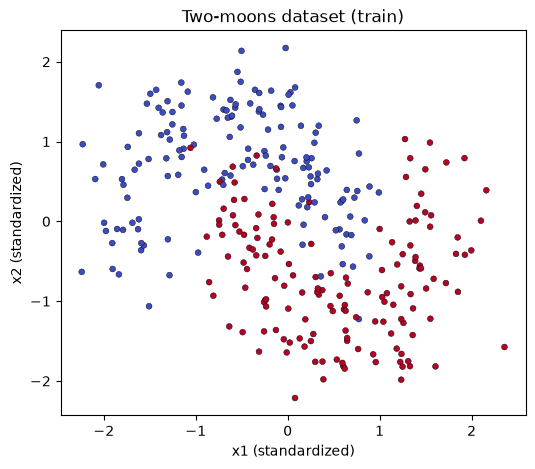

In [7]:
# Data generation + plotting helper - read-only cell; do not edit (but DO run it)
def make_clf_data(n, seed):
    X, y = make_moons(n_samples=n, noise=0.25, random_state=seed)
    return X.astype(np.float32), y.astype(np.int64)

Xm_tr, ym_tr = make_clf_data(300, SEED)
Xm_te, ym_te = make_clf_data(200, SEED + 1000)

clf_mean = Xm_tr.mean(axis=0)
clf_std = Xm_tr.std(axis=0)
X_clf      = torch.tensor((Xm_tr - clf_mean) / clf_std)   # (300, 2) float
y_clf      = torch.tensor(ym_tr)                          # (300,)   long
X_clf_test = torch.tensor((Xm_te - clf_mean) / clf_std)   # (200, 2) float
y_clf_test = torch.tensor(ym_te)                          # (200,)   long


def plot_decision_boundary(model, X, y, title="Decision boundary"):
    # Plot the 2D decision boundary of a classifier together with the data.
    X, y = X.numpy(), y.numpy()
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()].astype(np.float32))
    with torch.no_grad():
        zz = model(grid).argmax(dim=1).reshape(xx.shape).numpy()
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, s=18, cmap="coolwarm", edgecolors="k", linewidths=0.3)
    plt.title(title)
    plt.xlabel("x1 (standardized)")
    plt.ylabel("x2 (standardized)")
    plt.show()


print("X_clf:", tuple(X_clf.shape), "| y_clf:", tuple(y_clf.shape),
      "| X_clf_test:", tuple(X_clf_test.shape), "| y_clf_test:", tuple(y_clf_test.shape))

plt.figure(figsize=(6, 5))
plt.scatter(X_clf.numpy()[:, 0], X_clf.numpy()[:, 1], c=y_clf.numpy(), s=18,
            cmap="coolwarm", edgecolors="k", linewidths=0.3)
plt.title("Two-moons dataset (train)")
plt.xlabel("x1 (standardized)")
plt.ylabel("x2 (standardized)")
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">بحث کنید</h2>
<ul style="text-align: right;">
<li style="text-align: right;">آیا یک مرز تصمیم خطی (مثل رگرسیون لجستیک) می‌تواند این دو هلال را با دقت بالا جدا کند؟ حدوداً چند نمونه اشتباه می‌شود؟</li>
<li style="text-align: right;">مرز تصمیم «ایده‌آل» برای این داده چه شکلی است؟</li>
</ul>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۶ — پیاده‌سازی MLP برای دسته‌بندی</h2>
<p style="text-align: right;">حالا دسته‌بند خودتان را بنویسید. یک نکته‌ی مهم: <code dir="ltr">nn.CrossEntropyLoss</code> در PyTorch ترکیب <code dir="ltr">log-softmax</code> و <code dir="ltr">Negative log likelihood</code> است؛ یعنی مدل باید <strong>logit خام</strong> برگرداند و <strong>نباید</strong> softmax را در <code dir="ltr">forward</code> اعمال کنید:</p>
<pre dir="ltr">class MLPClassifier(nn.Module):
    def __init__(self, in_dim=2, hidden_dims=(32, 32), n_classes=2):
        ...
    def forward(self, x):
        ...  # returns logits, shape (n, n_classes)</pre>
<ul style="text-align: right;">
<li style="text-align: right;">معماری مثل قبل: برای هر لایه‌ی پنهان <code dir="ltr">Linear + ReLU</code>؛ لایه‌ی آخر <code dir="ltr">Linear</code> با <code dir="ltr">n_classes</code> خروجی (بدون فعال‌سازی).</li>
<li style="text-align: right;">برچسب‌ها باید از نوع <code dir="ltr">long</code> باشند (هستند) و پیش‌بینی کلاس با <code dir="ltr">logits.argmax(dim=1)</code> انجام می‌شود.</li>
</ul>
</div>


In [8]:
# TODO: Define the 'MLPClassifier' class (subclass of torch.nn.Module) with signature:
#   MLPClassifier(in_dim=2, hidden_dims=(32, 32), n_classes=2)
# Architecture: for each dim in hidden_dims, one nn.Linear followed by ReLU;
# then a final nn.Linear with n_classes outputs (raw logits, NO softmax).

class MLPClassifier(nn.Module):
    def __init__(self, in_dim=2, hidden_dims=(32, 32), n_classes=2):
        super().__init__()
        dims = [in_dim, *hidden_dims, n_classes]
        layers = []
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۶ (ادامه) — آموزش دسته‌بند و مقایسه با رگرسیون لجستیک</h2>
<ol style="text-align: right;">
<li style="text-align: right;">با seed ثابت مدل <code dir="ltr">MLPClassifier()</code> بسازید و با <code dir="ltr">torch.optim.Adam</code> (با <code dir="ltr">lr=0.01</code>) و <code dir="ltr">nn.CrossEntropyLoss()</code> برای ۴۰۰ گام آموزش دهید.</li>
<li style="text-align: right;">دقت (accuracy) مدل را روی داده‌ی آموزش و تست چاپ کنید.</li>
<li style="text-align: right;">با <code dir="ltr">sklearn.linear_model.LogisticRegression</code> یک خط پایه بسازید و دقت تست آن را چاپ کنید — تفاوت را ببینید!</li>
<li style="text-align: right;">مرز تصمیم MLP را با <code dir="ltr">plot_decision_boundary(model, X_clf, y_clf)</code> رسم کنید.</li>
</ol>
</div>


epoch  100 | loss = 0.111616
epoch  200 | loss = 0.094882
epoch  300 | loss = 0.082297
epoch  400 | loss = 0.073008
train accuracy = 0.9700 | test accuracy = 0.9600
logistic regression test accuracy = 0.8750


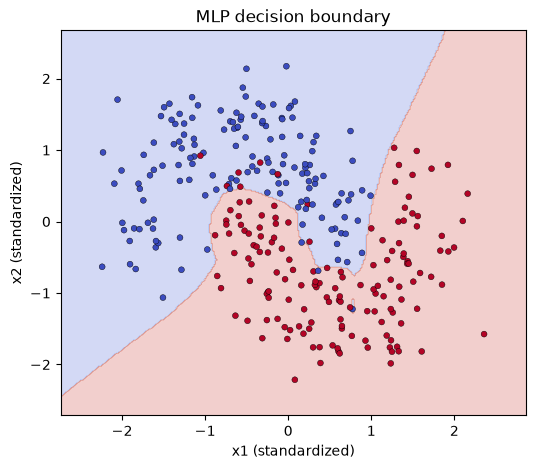

In [9]:
# TODO: train an MLPClassifier on the two-moons data:
#   torch.manual_seed(SEED); model = MLPClassifier()
#   define optimizer and loss_fn
#   losses = train_model(model, X_clf, y_clf, optimizer, loss_fn, epochs=400, log_every=100)

# TODO: compute and print train accuracy and test accuracy (you can predict class inside torch.no_grad())

# TODO: fit a sklearn LogisticRegression baseline on (X_clf.numpy(), y_clf.numpy())
#   and print its test accuracy on (X_clf_test.numpy(), y_clf_test.numpy()) for comparison


torch.manual_seed(SEED)
model = MLPClassifier()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()
losses = train_model(model, X_clf, y_clf, optimizer, loss_fn, epochs=400, log_every=100)

with torch.no_grad():
    train_acc = (model(X_clf).argmax(dim=1) == y_clf).float().mean().item()
    test_acc = (model(X_clf_test).argmax(dim=1) == y_clf_test).float().mean().item()
print(f"train accuracy = {train_acc:.4f} | test accuracy = {test_acc:.4f}")

baseline = LogisticRegression().fit(X_clf.numpy(), y_clf.numpy())
print(f"logistic regression test accuracy = "
      f"{baseline.score(X_clf_test.numpy(), y_clf_test.numpy()):.4f}")

plot_decision_boundary(model, X_clf, y_clf, title="MLP decision boundary")

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">بحث کنید</h2>
<ul style="text-align: right;">
<li style="text-align: right;">مرز تصمیم MLP با مرز تصمیم رگرسیون لجستیک چه فرقی دارد؟ MLP مرزش را از کجا «مثلثی/منحنی» ساخته است؟</li>
<li style="text-align: right;">در کدام نقاط داده شبکه‌ی شما اشتباه می‌کند؟ این نقاط چه ویژگی مشترکی دارند؟</li>
</ul>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۷ — بهینه‌ساز خودمان: گرادیان کاهشی ساده (VanillaGD)</h2>
<p style="text-align: right;">تا اینجا <code dir="ltr">optimizer.step()</code> یک جعبه‌ی سیاه بود؛ وقت باز کردنش است! بهینه‌ساز خودمان را می‌سازیم که دقیقاً همین قاعده‌ی آشنا را اجرا می‌کند:</p>

$$\theta \leftarrow \theta - \eta\, \nabla_\theta L(\theta)$$

<p style="text-align: right;">بعد از <code dir="ltr">loss.backward()</code> گرادیان هر پارامتر در <code dir="ltr">p.grad</code> در دسترس است؛ پس فقط باید آن را از پارامتر کم کنیم. کلاس زیر را پیاده کنید:</p>
<pre dir="ltr">class VanillaGD:
    def __init__(self, params, lr=0.1):
        ...
    def zero_grad(self):
        ...
    def step(self):
        ...</pre>
<ul style="text-align: right;">
<li style="text-align: right;"><code dir="ltr">params</code> ممکن است یک generator باشد (خروجی <code dir="ltr">model.parameters()</code>)؛ آن را با <code dir="ltr">list(...)</code> ذخیره کنید وگرنه بعد از اولین پیمایش خالی می‌شود!</li>
<li style="text-align: right;"><code dir="ltr">zero_grad()</code>: مقدار <code dir="ltr">p.grad</code> همه‌ی پارامترها را <code dir="ltr">None</code> کنید.</li>
<li style="text-align: right;"><code dir="ltr">step()</code>: هر پارامتر را با قاعده‌ی بالا به‌روزرسانی کنید — داخل بلاک <code dir="ltr">torch.no_grad()</code> (چرا؟ چون نمی‌خواهیم خودِ گامِ به‌روزرسانی در نمودار گرادیان ثبت شود).</li>
</ul>
<details style="text-align: right;"><summary style="text-align: right;">راهنمایی</summary><p style="text-align: right;">هسته‌ی <code dir="ltr">step</code> چیزی شبیه این است: <code dir="ltr">with torch.no_grad(): for p in self.params: p -= self.lr * p.grad</code></p></details>
</div>


In [10]:
# TODO: Define the 'VanillaGD' class with the following API:
#   VanillaGD(params, lr=0.1)   - params: iterable of tensors (store it as a list!)
#   .zero_grad()                - set .grad of every param to None
#   .step()                     - p <- p - lr * p.grad   (inside torch.no_grad())

class VanillaGD:
    def __init__(self, params, lr=0.1):
        self.params = [p for p in params if p.requires_grad]
        self.lr = lr

    def zero_grad(self):
        for p in self.params:
            p.grad = None

    def step(self):
        with torch.no_grad():
            for p in self.params:
                if p.grad is not None:
                    p -= self.lr * p.grad

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۷ (ادامه) — آزمایش VanillaGD</h2>
<p style="text-align: right;">بهینه‌ساز خودتان را امتحان کنید: یک <code dir="ltr">MLPRegressor()</code> تازه (با seed ثابت) را با <code dir="ltr">VanillaGD(lr=0.05)</code> برای ۳۰۰ گام روی داده‌ی رگرسیون آموزش دهید، منحنی هزینه را رسم کنید و هزینه‌ی نهایی را چاپ کنید. (مقدار مرجع حدود <b dir="ltr">0.024</b> است — نزدیک کفِ نویز داده.)</p>
</div>


epoch  100 | loss = 0.076946
epoch  200 | loss = 0.028307
epoch  300 | loss = 0.031101


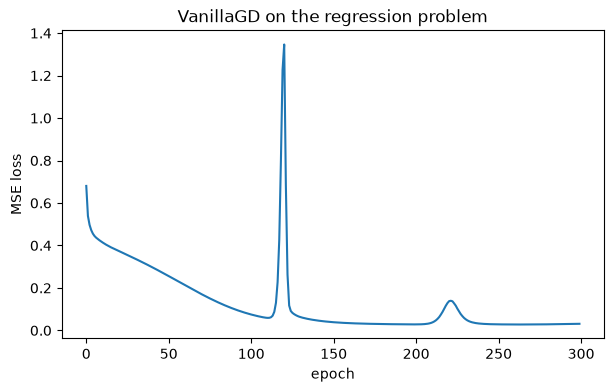

final loss = 0.0311


In [11]:
# TODO: train a fresh MLPRegressor (default architecture) with your VanillaGD:
#   torch.manual_seed(SEED); model = MLPRegressor()
#   define the optimizer and loss_fn
#   losses = train_model(model, X_reg, y_reg, optimizer, loss_fn, epochs=300, log_every=100)


torch.manual_seed(SEED)
model = MLPRegressor()
optimizer = VanillaGD(model.parameters(), lr=0.05)
loss_fn = nn.MSELoss()
losses = train_model(model, X_reg, y_reg, optimizer, loss_fn, epochs=300, log_every=100)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("VanillaGD on the regression problem")
plt.show()

print(f"final loss = {losses[-1]:.4f}")

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">بحث کنید</h2>
<ul style="text-align: right;">
<li style="text-align: right;">اگر نرخ یادگیری را ۱۰ برابر بزرگ‌تر یا کوچک‌تر کنید چه اتفاقی می‌افتد؟</li>
<li style="text-align: right;">چرا هر گام باید گرادیان قبلی را صفر کنیم؟ اگر این کار را نکنیم دقیقاً چه اتفاقی می‌افتد؟</li>
</ul>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۸ — مومنتوم (MomentumGD)</h2>
<p style="text-align: right;">گرادیان کاهشی ساده روی بعضی مسیرها کُند است: وقتی سطح هزینه یک «دره‌ی باریک و کشیده» باشد، GD در دیواره‌های تند نوسان می‌کند اما در کفِ کم‌شیب خیلی آهسته جلو می‌رود. ایده‌ی <strong>مومنتوم</strong>: به‌جای گام‌های مستقل، یک «سرعت» انباشته از گرادیان‌های قبلی نگه داریم — مثل توپی که در دره می‌غلتد و گرانش (گرادیان) کم‌کم جهتش را اصلاح می‌کند:</p>

$$v_t = \beta\, v_{t-1} + \nabla_\theta L(\theta_t)$$

$$\theta_{t+1} = \theta_t - \eta\, v_t$$

<ul style="text-align: right;">
<li style="text-align: right;">$v_t$ ترکیب نمایی گرادیان‌های اخیر است؛ با $\beta = 0.9$ اثر هر گرادیان حدود ۱۰ گام باقی می‌ماند.</li>
<li style="text-align: right;">در جهاتی که گرادیان هم‌جهت است، سرعت جمع می‌شود (شتاب) و در جهاتی که نوسانی است، خنثی می‌شود (میرایی).</li>
<li style="text-align: right;">همین ایده داخل <code dir="ltr">torch.optim.SGD(momentum=0.9)</code> هم پیاده شده است.</li>
</ul>
<p style="text-align: right;">کلاس <code dir="ltr">MomentumGD</code> را با همان API فاز ۷ پیاده کنید:</p>
<pre dir="ltr">class MomentumGD:
    def __init__(self, params, lr=0.1, beta=0.9):
        ...
    def zero_grad(self):
        ...
    def step(self):
        ...</pre>
<p style="text-align: right;">برای هر پارامتر یک «سرعت» جداگانه لازم دارید: در سازنده با <code dir="ltr">torch.zeros_like(p)</code> مقدار اولیه‌ی صفر بدهید. در <code dir="ltr">step</code> اول سرعت را به‌روزرسانی کنید و بعد پارامتر را.</p>
</div>


In [12]:
# TODO: Define the 'MomentumGD' class with the following API:
#   MomentumGD(params, lr=0.1, beta=0.9)  - params: iterable of tensors (store as a list!)
#   .zero_grad()                          - set .grad of every param to None
#   .step()                               - v <- beta * v + p.grad ;  p <- p - lr * v
# Keep one velocity tensor (torch.zeros_like) per parameter, initialized in __init__.

class MomentumGD:
    def __init__(self, params, lr=0.1, beta=0.9):
        self.params = [p for p in params if p.requires_grad]
        self.lr = lr
        self.beta = beta
        self.velocities = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        for p in self.params:
            p.grad = None

    def step(self):
        with torch.no_grad():
            for p, v in zip(self.params, self.velocities):
                if p.grad is not None:
                    v.mul_(self.beta).add_(p.grad)
                    p -= self.lr * v

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۸ (ادامه) — مقایسه‌ی همگرایی: VanillaGD در برابر MomentumGD</h2>
<p style="text-align: right;">حالا دو بهینه‌ساز را در شرایط یکسان مسابقه بدهیم. یک شبکه‌ی <strong>عمیق‌تر</strong> — <code dir="ltr">MLPRegressor(hidden_dims=(64, 64, 64))</code> — با <code dir="ltr">lr=0.02</code> و فقط <strong>۲۰۰ گام</strong> آموزش دهید؛ دو بار، هر بار با یک بهینه‌ساز:</p>
<ol style="text-align: right;">
<li style="text-align: right;"><code dir="ltr">torch.manual_seed(SEED)</code>؛ مدل A را با <code dir="ltr">VanillaGD(lr=0.02)</code> آموزش دهید.</li>
<li style="text-align: right;">دوباره <code dir="ltr">torch.manual_seed(SEED)</code>؛ مدل B را با <code dir="ltr">MomentumGD(lr=0.02, beta=0.9)</code> آموزش دهید.</li>
<li style="text-align: right;">هر دو منحنی هزینه را در <strong>یک شکل</strong> (با legend) رسم کنید و دو هزینه‌ی نهایی را چاپ کنید.</li>
</ol>
<p style="text-align: right;">seed یکسان تضمین می‌کند هر دو مدل از نقطه‌ی شروع یکسان شروع کنند؛ پس هر تفاوتی که می‌بینید فقط از بهینه‌ساز است. با توجه به lr نسبتاً کوچک، انتظار داریم GD ساده هنوز وسط راه باشد ولی مومنتوم به کفِ نویز برسد — مقدار مرجع را در فاز ارزیابی ببینید.</p>
</div>


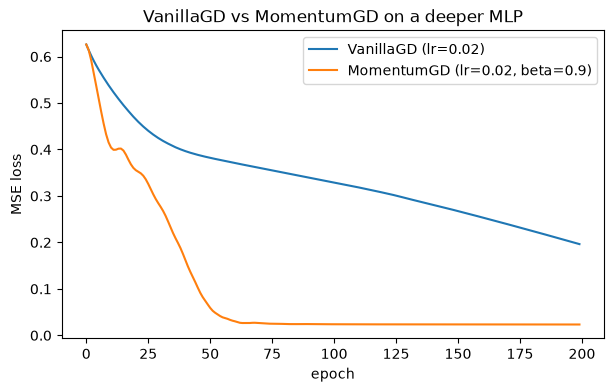

VanillaGD final loss  = 0.1964
MomentumGD final loss = 0.0234


In [13]:
# TODO: compare the two optimizers on a deeper network (same init for both):
#   torch.manual_seed(SEED)
#   m_vanilla = MLPRegressor(hidden_dims=(64, 64, 64))
#   losses_vanilla = train_model(m_vanilla, X_reg, y_reg,
#                                VanillaGD(m_vanilla.parameters(), lr=0.02),
#                                nn.MSELoss(), epochs=200, log_every=None)
#
#   torch.manual_seed(SEED)
#   m_moment = MLPRegressor(hidden_dims=(64, 64, 64))
#   losses_moment = train_model(m_moment, X_reg, y_reg,
#                               MomentumGD(m_moment.parameters(), lr=0.02, beta=0.9),
#                               nn.MSELoss(), epochs=200, log_every=None)


torch.manual_seed(SEED)
m_vanilla = MLPRegressor(hidden_dims=(64, 64, 64))
losses_vanilla = train_model(m_vanilla, X_reg, y_reg,
                             VanillaGD(m_vanilla.parameters(), lr=0.02),
                             nn.MSELoss(), epochs=200, log_every=None)

torch.manual_seed(SEED)
m_moment = MLPRegressor(hidden_dims=(64, 64, 64))
losses_moment = train_model(m_moment, X_reg, y_reg,
                            MomentumGD(m_moment.parameters(), lr=0.02, beta=0.9),
                            nn.MSELoss(), epochs=200, log_every=None)

# TODO: plot both loss curves in ONE figure (with a legend) and print the two final losses
plt.figure(figsize=(7, 4))
plt.plot(losses_vanilla, label="VanillaGD (lr=0.02)")
plt.plot(losses_moment, label="MomentumGD (lr=0.02, beta=0.9)")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("VanillaGD vs MomentumGD on a deeper MLP")
plt.legend()
plt.show()

print(f"VanillaGD final loss  = {losses_vanilla[-1]:.4f}")
print(f"MomentumGD final loss = {losses_moment[-1]:.4f}")

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">بحث کنید</h2>
<ul style="text-align: right;">
<li style="text-align: right;">چرا مومنتوم اینجا خیلی سریع‌تر همگرا شد؟ در چه شکلی از سطح خطا مزیت مومنتوم بیشترین مقدار را دارد؟</li>
<li style="text-align: right;">آیا مومنتوم می‌تواند ضرر هم بزند؟ (سرنخ: $\beta$ نزدیک ۱ با $\eta$ بزرگ چه می‌کند؟)</li>
<li style="text-align: right;">رابطه‌ی کلاس شما با <code dir="ltr">torch.optim.SGD(momentum=0.9)</code> چیست؟ می‌توانید نتیجه‌شان را مقایسه کنید؟</li>
</ul>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ارزیابی — نتیجه‌ی کار خودتان را ببینید</h2>
<p style="text-align: right;">سلول زیر با seed ثابت و مشخصات از پیش تعیین‌شده، سه آزمون را از صفر اجرا می‌کند:</p>
<ul style="text-align: right;">
<li style="text-align: right;"><strong>[۱/۳] رگرسیون:</strong> آموزش یک <code dir="ltr">MLPRegressor</code> با Adam و محاسبه‌ی MSE روی داده‌ی تست رگرسیون</li>
<li style="text-align: right;"><strong>[۲/۳] دسته‌بندی:</strong> آموزش یک <code dir="ltr">MLPClassifier</code> با Adam و محاسبه‌ی دقت روی داده‌ی تست دو هلال</li>
<li style="text-align: right;"><strong>[۳/۳] بهینه‌سازها:</strong> آموزش شبکه‌ی عمیق‌تر <code dir="ltr">(64, 64, 64)</code> با <code dir="ltr">VanillaGD</code> و <code dir="ltr">MomentumGD</code> (با lr=0.02 و ۲۰۰ گام) و مقایسه‌ی هزینه‌ی نهایی</li>
</ul>
<p style="text-align: right;">اگر همه‌ی بخش‌ها را مطابق مشخصات پیاده کرده باشید، باید اعدادی نزدیک به مقادیر مرجع ببینید (اختلاف جزئی طبیعی است).</p>
<p style="text-align: right;">مقدار مورد انتظار راه‌حل مرجع: <b dir="ltr">test MSE ≈ 0.0214 | test acc ≈ 0.9150 | VanillaGD loss ≈ 0.1746 | MomentumGD loss ≈ 0.0215</b></p>
<p style="text-align: right;color: var(--jp-ui-font-color2, #6b7280);">خروجی سلول مرجع زیر (که اجرا نمی‌کنید) مقدار راه‌حل طراح را نشان می‌دهد — نتیجه‌ی خودتان را با آن مقایسه کنید.</p>
</div>


In [14]:
# Evaluation cell - run it and compare your results with the reference values
print("=" * 62)

# [1/3] MLP regressor trained with Adam -> test MSE
torch.manual_seed(SEED)
reg = MLPRegressor()
opt = torch.optim.Adam(reg.parameters(), lr=0.01)
train_model(reg, X_reg, y_reg, opt, nn.MSELoss(), epochs=400, log_every=None)
with torch.no_grad():
    test_mse = nn.MSELoss()(reg(X_reg_test), y_reg_test).item()
print(f"[1/3] MLP regressor (Adam)      -> test MSE  = {test_mse:.4f}")

# [2/3] MLP classifier trained with Adam -> test accuracy
torch.manual_seed(SEED)
clf = MLPClassifier()
opt = torch.optim.Adam(clf.parameters(), lr=0.01)
train_model(clf, X_clf, y_clf, opt, nn.CrossEntropyLoss(), epochs=400, log_every=None)
with torch.no_grad():
    test_acc = (clf(X_clf_test).argmax(dim=1) == y_clf_test).float().mean().item()
print(f"[2/3] MLP classifier (Adam)     -> test acc  = {test_acc:.4f}")

# [3/3] deep MLP trained with VanillaGD vs MomentumGD -> final train losses
torch.manual_seed(SEED)
m_vanilla = MLPRegressor(hidden_dims=(64, 64, 64))
losses_vanilla = train_model(m_vanilla, X_reg, y_reg,
                             VanillaGD(m_vanilla.parameters(), lr=0.02),
                             nn.MSELoss(), epochs=200, log_every=None)
torch.manual_seed(SEED)
m_moment = MLPRegressor(hidden_dims=(64, 64, 64))
losses_moment = train_model(m_moment, X_reg, y_reg,
                            MomentumGD(m_moment.parameters(), lr=0.02, beta=0.9),
                            nn.MSELoss(), epochs=200, log_every=None)
print(f"[3/3] deep MLP, lr=0.02, 200 ep -> VanillaGD loss = {losses_vanilla[-1]:.4f} | "
      f"MomentumGD loss = {losses_moment[-1]:.4f}")
print("=" * 62)

[1/3] MLP regressor (Adam)      -> test MSE  = 0.0240
[2/3] MLP classifier (Adam)     -> test acc  = 0.9600
[3/3] deep MLP, lr=0.02, 200 ep -> VanillaGD loss = 0.1964 | MomentumGD loss = 0.0234


In [15]:
# Reference cell - do NOT run it (kept for comparison only)
# Designer's reference output (same seeds and specifications as the evaluation cell):